# JM0110 Tutorial on Counterfactual Explanation methods

This tutorial covers the following:


*   Simple example presented in slides
*   Counterfactuals in Tabular data
*   Counterfactuals in Images
*   Counterfactuals in Text
*   Open questions for you to answer!

In [3]:
# load python packages
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

## A simple example of counterfactual explanations

In [4]:
# loan application model
def f(x):
  income, loan_amount = x
  f = 0.2 * income - 0.3 * loan_amount
  if f >= 1000:
    return 1
  else:
    return 0

# Example loan application
f([20000,11000]) # income = 20000 , loan_amount = 11000 --> loan not approved (0)

0

In [5]:
def loss_function(x_prime, x_orig, target, lambda_):
    """Wachter et al.'s loss function: distance + classification constraint."""
    pred = f(x_prime)
    distance = np.linalg.norm((x_prime - x_orig) / x_orig, ord=2)  # L2 distance with feature scaling
    return lambda_ * (pred - target)**2 + distance

# Example of how the loss function works. Here we are trying to balance crossing the decision boundary and producing a minimal example. The lower the value the better.
print(loss_function(np.array([25000, 10500]), np.array([20000,11000]), 1, 0.1))

0.25409863380679426


In [6]:
def generate_counterfactual(x_orig, target=1, tol=1, lambda_init=0.1, lambda_step=10, max_iter=10):
  counterfactuals = []
  lambda_ = lambda_init
  # Randomly sample an initial counterfactual
  x_cf = x_orig + np.random.uniform(-0.3, 0.3, size=x_orig.shape) * x_orig
  for _ in range(max_iter):
    # optimize loss with initial sample x_cf
    result = opt.minimize(loss_function, x_cf, args=(x_orig, target, lambda_), method='Powell')
    # store results
    x_cf = result.x
    counterfactuals.append(x_cf)
    # if |f(x') - y'| > epsilon
    if abs(f(x_cf) - target) > tol:
      lambda_ += lambda_step
  # Return the most minimal counterfactual found
  return min(counterfactuals, key=lambda x: loss_function(x, x_orig, target, lambda_)) if counterfactuals else None

x_orig = np.array([20000,11000])
print(f"Original: Income = {x_orig[0]}, Loan Amount = {x_orig[1]}")
print("Original prediction f(x) = ", f(x_orig))
x_cf = generate_counterfactual(x_orig)
print(f"Counterfactual: Income = {x_cf[0]}, Loan Amount = {x_cf[1]}")
print("Counterfactual prediction f(x') = ", f(x_cf))

Original: Income = 20000, Loan Amount = 11000
Original prediction f(x) =  0
Counterfactual: Income = 21438.68638771354, Loan Amount = 10959.124258475687
Counterfactual prediction f(x') =  1


Try re-running the above code... the end result can change! This is because we randomly initialize the counterfactual, which can lead to slightly different outcomes. Now let's visualize the example:

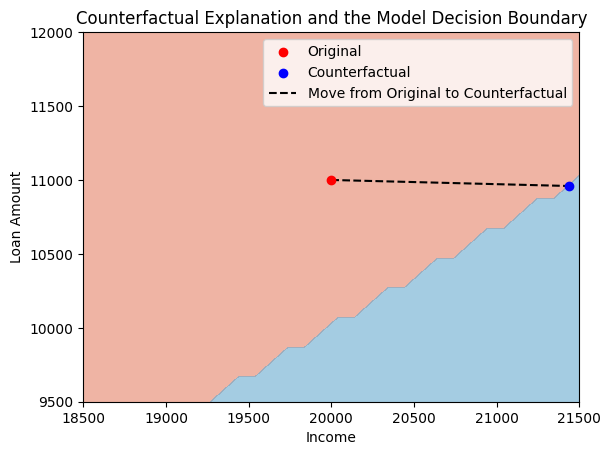

In [7]:
# Visualize with zoom-in on crossing region
x_min, x_max = 0, 50000
y_min, y_max = 0, 50000

# Creating grid of points for decision boundary visualization
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
Z = np.array([f(np.array([i, j])) for i, j in zip(xx.ravel(), yy.ravel())])
Z = Z.reshape(xx.shape)


# Plot decision boundary with color shading
plt.contourf(xx, yy, Z, levels=[0,0.5,1], cmap="RdBu", alpha=0.6)

# Zoom into region around decision boundary
plt.xlim(x_orig[0] - 1500, x_orig[0] + 1500)
plt.ylim(x_orig[1] - 1500, x_orig[1] + 1000)

# Plot original and counterfactual points
plt.scatter(x_orig[0], x_orig[1], color='red', label='Original', zorder=5)
plt.scatter(x_cf[0], x_cf[1], color='blue', label='Counterfactual', zorder=5)

# Add dotted line showing move from original to counterfactual
plt.plot([x_orig[0], x_cf[0]], [x_orig[1], x_cf[1]], 'k--', label='Move from Original to Counterfactual')

# Add labels and title
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.title('Counterfactual Explanation and the Model Decision Boundary')
plt.legend()
plt.show()

### **Open Question 1**

You may have noticed when re-running this example that in some cases the counterfactual returns an invalid example i.e. the decision did not change! The quality of the counterfactual can change depending on the parameters you choose. There are many parameters in the above example that can impact the counterfactual explanation. For instance:


*   tol = tolerance: or epsilon. It is the tolerated distance between the prediction of the counterfactual instance and y'
*   lambda_init = lambda: the parameter that balances the distance in prediction against the distance in feature values. This is the initial value.
* lambda_step: by how much lambda should increase by when the equation is not satisfied.
* max_iter = maximum iterations: counterfactuals can get stuck and therefore we need to define the maximum number of iterations it can go for.


Can you play around with these different parameters? How does the validity of the counterfactual change if at all? A certain parameter choices better? Why?

You can also look at changing the initialization step of randomly sampling a counterfactual by increasing or decreasing the range (currently set to 0.3) or the original instance x. When changing x make sure that the model prediction starts as 0, 'loan denied'.


If you want you can add complexity by changing the model f(x) or even train your own model and test it again!

**Add answer here:**

## For the next 2 open questions we will be working with open source python packages that implement counterfactual explanations specifically. Unfortunatley both require specific virtual environments so in order to work with them you need to leave this notebook and open a conda env/venv on your laptop and follow the installation instructions.




## Counterfactual explanations in Tables

Because of dependency issues with the package, this part of the tutorial should not be exectuted in this notebook but instead you should download the DiCE package from github and follow the installation intructions here: https://github.com/interpretml/DiCE



```
To install the latest (dev) version of DiCE and its dependencies,
clone this repo and run pip install from the top-most folder of the repo:

pip install -e .


If you face any problems, try installing dependencies manually.

pip install -r requirements.txt
# Additional dependendies for deep learning models
pip install -r requirements-deeplearning.txt
# For running unit tests
pip install -r requirements-test.txt
```




Once correctly installed, you should be able to run the 'getting started' code:

In [8]:
import dice_ml
from dice_ml.utils import helpers # helper functions
from sklearn.model_selection import train_test_split

dataset = helpers.load_adult_income_dataset()
target = dataset["income"] # outcome variable
train_dataset, test_dataset, _, _ = train_test_split(dataset,
                                                     target,
                                                     test_size=0.2,
                                                     random_state=0,
                                                     stratify=target)
# Dataset for training an ML model
d = dice_ml.Data(dataframe=train_dataset,
                 continuous_features=['age', 'hours_per_week'],
                 outcome_name='income')

# Pre-trained ML model
m = dice_ml.Model(model_path=dice_ml.utils.helpers.get_adult_income_modelpath(),
                  backend='TF2', func="ohe-min-max")
# DiCE explanation instance
exp = dice_ml.Dice(d,m)

c:\Users\rderi\OneDrive\Bureaublad\Jads 2025-2027\SM2-Jads-Courses\Interactive & Explainable AI Design\CounterFactuals Tutorial\DiCE\dice_ml\utils\helpers.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adult_data = adult_data.replace({'income': {'<=50K': 0, '>50K': 1}})
c:\Users\rderi\OneDrive\Bureaublad\Jads 2025-2027\SM2-Jads-Courses\Interactive & Explainable AI Design\CounterFactuals Tutorial\DiCE\.venvDice\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\rderi\OneDrive\Bureaublad\Jads

In [9]:
# Generate counterfactual examples
query_instance = test_dataset.drop(columns="income")[0:1]
dice_exp = exp.generate_counterfactuals(query_instance, total_CFs=4, desired_class="opposite")
# Visualize counterfactual explanation
dice_exp.visualize_as_dataframe()

100%|██████████| 1/1 [00:01<00:00,  1.30s/it]

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,82,Private,Assoc,Married,Blue-Collar,White,Female,38,1
1,29,Private,Bachelors,Married,Blue-Collar,White,Female,38,1
2,47,Private,HS-grad,Married,Blue-Collar,White,Female,89,1
3,29,Other/Unknown,Prof-school,Married,Blue-Collar,White,Female,38,1


The output should look something like this:

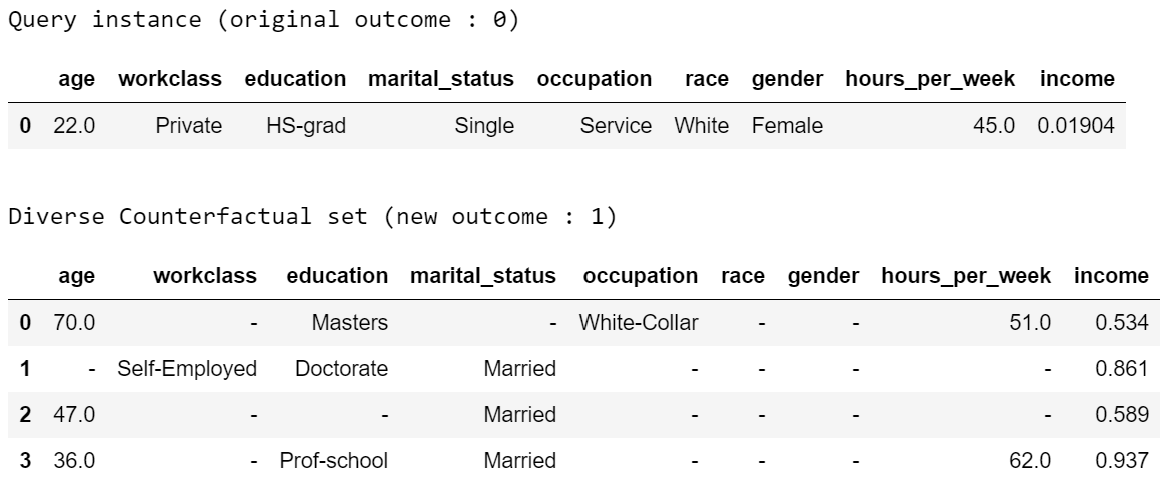

### **Open Question 2**
In today's lecture, we talked about various methods that you can use to generate counterfactual explanations (Random sampling, KD-Tree, Genetic Algorithm). In the line:


```
exp = dice_ml.Dice(d,m)
```

You can add a variable

```
exp_random = Dice(d, m, method="random")
```
to fit the different methods available. Try to experiment with the different methods and look at easy to compute metrics like running time and validity (crosses the decision boundary). Which method works best?


**Add answer here:**

## Counterfactual explanations in Images

In [8]:
# See for details: https://docs.seldon.io/projects/alibi/en/stable/examples/cf_mnist.html

#! pip install alibi

Again because of dependency issues it would be better to run this in a virtual environment. The exact python version you need is 3.9.18, with the requirements.txt file containing:



```
absl-py==2.1.0
alibi==0.9.6
annotated-types==0.7.0
astunparse==1.6.3
attrs==23.2.0
blis==0.7.11
cachetools==5.5.0
catalogue==2.0.10
certifi==2024.8.30
charset-normalizer==3.3.2
click==8.1.7
cloudpathlib==0.19.0
confection==0.1.5
contourpy==1.3.0
cycler==0.12.1
cymem==2.0.8
dill==0.3.8
filelock==3.16.0
flatbuffers==24.3.25
fonttools==4.53.1
fsspec==2024.9.0
gast==0.4.0
google-auth==2.34.0
google-auth-oauthlib==1.0.0
google-pasta==0.2.0
grpcio==1.66.1
h5py==3.1.0
huggingface-hub==0.24.7
idna==3.8
imageio==2.35.1
importlib_metadata==8.5.0
importlib_resources==6.4.5
jax==0.4.30
jaxlib==0.4.30
Jinja2==3.1.4
joblib==1.4.2
keras==2.12.0
keras-nightly==2.5.0.dev2021032900
Keras-Preprocessing==1.1.2
kiwisolver==1.4.7
langcodes==3.4.0
language_data==1.2.0
lazy_loader==0.4
libclang==18.1.1
marisa-trie==1.2.0
Markdown==3.7
markdown-it-py==3.0.0
MarkupSafe==2.1.5
matplotlib==3.9.2
mdurl==0.1.2
ml-dtypes==0.4.0
murmurhash==1.0.10
namex==0.0.8
networkx==3.2.1
numpy==1.23.0
oauthlib==3.2.2
opt-einsum==3.3.0
optree==0.12.1
packaging==24.1
pandas==2.2.2
pillow==10.4.0
preshed==3.0.9
protobuf==3.20.3
pyasn1==0.6.1
pyasn1_modules==0.4.1
pydantic==2.9.1
pydantic_core==2.23.3
Pygments==2.18.0
pyparsing==3.1.4
python-dateutil==2.9.0.post0
pytz==2024.2
PyYAML==6.0.2
regex==2024.9.11
requests==2.32.3
requests-oauthlib==2.0.0
rich==13.8.1
rsa==4.9
safetensors==0.4.5
scikit-image==0.22.0
scikit-learn==1.5.2
scipy==1.13.1
shellingham==1.5.4
six==1.15.0
smart-open==7.0.4
spacy==3.8.0
spacy-legacy==3.0.12
spacy-loggers==1.0.5
spacy-lookups-data==1.0.5
srsly==2.4.8
tensorboard==2.12.3
tensorboard-data-server==0.7.2
tensorboard-plugin-wit==1.8.1
tensorflow==2.12.0
tensorflow-estimator==2.12.0
tensorflow-io-gcs-filesystem==0.37.1
termcolor==1.1.0
thinc==8.2.5
threadpoolctl==3.5.0
tifffile==2024.8.30
tokenizers==0.19.1
torch==2.4.1
tqdm==4.66.5
transformers==4.44.2
typer==0.12.5
typing_extensions==4.12.2
tzdata==2024.1
urllib3==2.2.3
wasabi==1.1.3
weasel==0.4.1
Werkzeug==3.0.4
wrapt==1.12.1
zipp==3.20.1
```



In [2]:
# Try to import these packages
import tensorflow as tf
tf.compat.v1.disable_v2_behavior() # disable TF2 behaviour as alibi code still relies on TF1 constructs
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Dropout, GlobalAveragePooling2D, Dense, Input, Conv2D, MaxPooling2D, Flatten, Layer
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from time import time
from alibi.explainers import Counterfactual,  CounterfactualProto, CEM
import pandas as pd
import os
import os.path
import argparse
import torch
import pathlib

Instructions for updating:
non-resource variables are not supported in the long term


In this section, we will be using the alibi package for generating counterfactual explanations. Download the pre-trained model from [here](https://drive.google.com/file/d/15hIlg_c8sYGLRV2tu9aFvl8Ml3UmHk5Y/view?usp=sharing) and load it below along with the dataset:

In [3]:
# load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
x_train = np.reshape(x_train, x_train.shape + (1,))
x_test = np.reshape(x_test, x_test.shape + (1,))
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
xmin, xmax = -1, 1
x_train = ((x_train - x_train.min()) / (x_train.max() - x_train.min())) * (xmax - xmin) + xmin
x_test = ((x_test - x_test.min()) / (x_test.max() - x_test.min())) * (xmax - xmin) + xmin

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
model = load_model('mnist_alibi_cnn.h5') # if you want you can train your own model here!

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Now, follow the notebook and generate some counterfactuals. How do they look like?

In [9]:
shape = (1,) + x_train.shape[1:]
target_proba = 1.0
tol = 0.01 # want counterfactuals with p(class)>0.99
target_class = 'other' # any class other than 7 will do
max_iter = 1000
lam_init = 1e-1
max_lam_steps = 10
learning_rate_init = 0.1
feature_range = (x_train.min(),x_train.max())

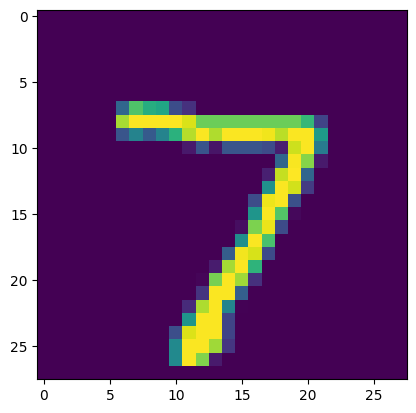

In [10]:
X = x_test[0].reshape((1,) + x_test[0].shape)
plt.imshow(X.reshape(28, 28));

In [ ]:
# initialize explainer
cf = Counterfactual(model, shape=shape, target_proba=target_proba, tol=tol,
                    target_class=target_class, max_iter=max_iter, lam_init=lam_init,
                    max_lam_steps=max_lam_steps, learning_rate_init=learning_rate_init,
                    feature_range=feature_range)

start_time = time()
explanation = cf.explain(X)
print('Explanation took {:.3f} sec'.format(time() - start_time))

You can also look at the explanation progression with:

In [ ]:
n_cfs = np.array([len(explanation.all[iter_cf]) for iter_cf in range(max_lam_steps)])
examples = {}
for ix, n in enumerate(n_cfs):
    if n>0:
        examples[ix] = {'ix': ix, 'lambda': explanation.all[ix][0]['lambda'],
                       'X': explanation.all[ix][0]['X']}
columns = len(examples) + 1
rows = 1

fig = plt.figure(figsize=(16,6))

for i, key in enumerate(examples.keys()):
    ax = plt.subplot(rows, columns, i+1)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.imshow(examples[key]['X'].reshape(28,28))
    plt.title(f'Iteration: {key}')

### **Open Question 3**

Again there are a lot of parameters here. Try to experiment with them. Look at different target classes. Do these explanations make sense? Are they able to generate something at all? Which parameters control the quality of explanations best?

**Add answer here:**